In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
df=pd.read_csv("solar_system.csv")
df.shape
df
#Shape is 20rows 11 columns
print(df.head())
print (df.tail())
print (df.columns)



,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [15]:
orbital_period = df.iloc[10, 1:].astype(float)
perihelion = df.iloc[8, 1:].astype(float)
aphelion = df.iloc[9, 1:].astype(float)
#Orbital Period is time it takes to orbit once, aphelion is is farthest point from sun in orbit, parhelion is closest to sun in orbit. 
semi_major_axis = (perihelion + aphelion) / 2
print(semi_major_axis)

Mercury      57.9000
Venus       108.2000
Earth       149.6000
Moon          0.3845
Mars        228.0000
Jupiter     778.5000
Saturn     1432.0500
Uranus     2867.0500
Neptune    4515.0000
Pluto      5906.3500
dtype: float64


In [21]:
semi_major_axis_row = pd.Series(
    ["Semi-major Axis (10^6 km)"] + list(semi_major_axis),
    index=df.columns
)
df = pd.concat([df, semi_major_axis_row.to_frame().T], ignore_index=True)
df.head()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [22]:
df = df.drop(df.index[-2:])

In [23]:
df

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


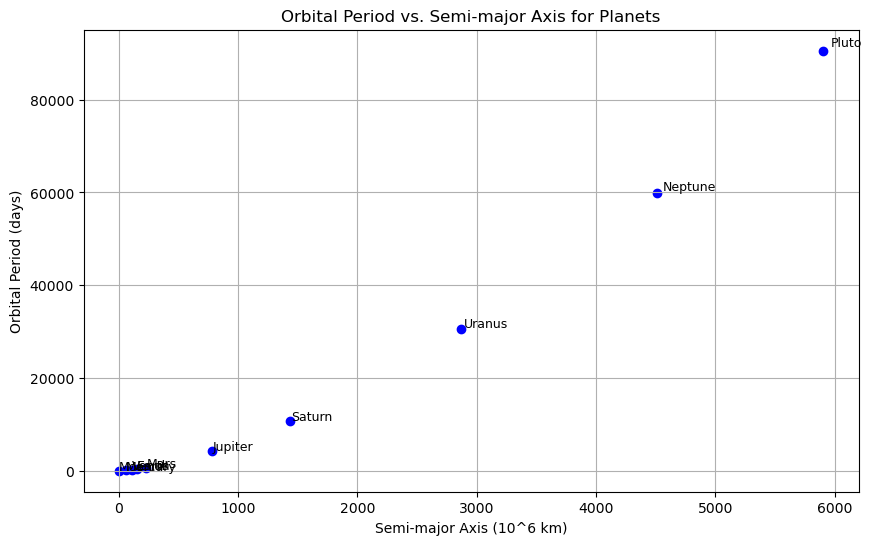

In [24]:
#There are now 21 rows and the same nuber of columns. 
plt.figure(figsize=(10,6))
plt.scatter(semi_major_axis, orbital_period, color='blue', label='Planets')
for planet in semi_major_axis.index:
    plt.text(semi_major_axis[planet]*1.01, orbital_period[planet]*1.01, planet, fontsize=9)
plt.xlabel('Semi-major Axis (10^6 km)')
plt.ylabel('Orbital Period (days)')
plt.title('Orbital Period vs. Semi-major Axis for Planets')
plt.legend
plt.grid(True)
plt.show()

In [40]:
def keplers_third_law(a, m):
    return m * a ** 1.5
a = df.iloc[20, 1:].astype(float)
P = df.iloc[10, 1:].astype(float)
popt, pcov = curve_fit(keplers_third_law, a, P,)
m_fit = popt
m_fit_new= np.round(m_fit,2)
print(f"Best-fit m: {m_fit_new}")


Best-fit m: [0.2]


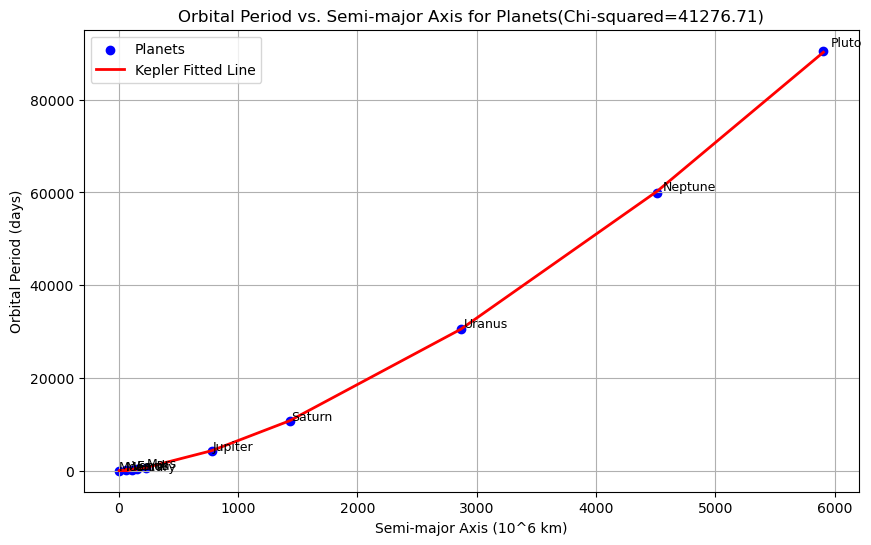

In [49]:
plt.figure(figsize=(10,6))
plt.scatter(semi_major_axis, orbital_period, color='blue', label='Planets')
x_line = df.iloc[20, 1:].astype(float)
y_line = m_fit * a ** 1.5
plt.plot(x_line, y_line, color='red', linewidth=2, label='Kepler Fitted Line')
for planet in semi_major_axis.index:
    plt.text(semi_major_axis[planet]*1.01, orbital_period[planet]*1.01, planet, fontsize=9)
plt.xlabel('Semi-major Axis (10^6 km)')
plt.ylabel('Orbital Period (days)')
residuals = a- keplers_third_law(a,m_fit)
chi2 = np.sum(residuals**2)
dof = len(a) - len(popt)
chi2_reduced = chi2 / dof
plt.title(f"Orbital Period vs. Semi-major Axis for Planets(Chi-squared={round(chi2_reduced,2)})")
plt.legend ()
plt.grid(True)
plt.show()

In [52]:
df.to_csv("kepler.csv", index=False)